# 01 — LightGBM optimisé + PCA (Fraud Detection)

**Pipeline LightGBM uniquement, avec réduction de dimension PCA :**

- Feature engineering avancé (UID, frequency encoding, group aggregations, ratios, z-scores)
- Imputation `-999` + split temporel 60/20/20
- ⭐ **StandardScaler + PCA** (réduction de dimension)
- LightGBM (`num_leaves=512`, `lr=0.03`, early stopping sur AUC-PR)
- Évaluation AUC-ROC + AUC-PR + courbes
- Réentraînement sur 100% des données labellisées + soumission Kaggle


## 1. Imports

In [1]:
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import lightgbm as lgb
import warnings; warnings.filterwarnings('ignore')

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/train_base.pkl')
test_kaggle  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/test_kaggle.pkl')
print(f'Train: {train.shape} | Test Kaggle: {test_kaggle.shape}')


Train: (590540, 427) | Test Kaggle: (506691, 426)


## 2. ⭐ UID client précis

`D1` = jours depuis la 1ère transaction de cette carte.
→ `day - D1` = **jour de création de la carte** (invariant pour un même client).
Combiné avec `card1 + addr1`, ça identifie un client de manière quasi-unique.

In [2]:
for df in [train, test_kaggle]:
    df['day'] = df['TransactionDT'] // (24*60*60)
    df['D1n'] = df['day'] - df['D1']
    # UID unique et précis
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].astype(str) + '_' +
                 df['D1n'].astype(str))
    # Combos pour frequency encoding
    df['card1_addr1']         = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    df['card1_addr1_P_email'] = df['card1_addr1'] + '_' + df['P_emaildomain'].astype(str)
    # outsider15
    df['outsider15'] = (np.abs(df['D1'].fillna(0) - df['D15'].fillna(0)) > 3).astype(np.int8)

print(f"UIDs uniques train: {train['uid'].nunique():,}")
print(f"UIDs uniques test:  {test_kaggle['uid'].nunique():,}")
print(f"Transactions/UID (moy): {len(train) / train['uid'].nunique():.1f}")

UIDs uniques train: 217,850
UIDs uniques test:  196,187
Transactions/UID (moy): 2.7


## 3. Frequency encoding (sur train + test_kaggle combiné)

In [3]:
FE_COLS = ['card1','card2','card3','card5','addr1','addr2',
           'P_emaildomain','R_emaildomain',
           'uid','card1_addr1','card1_addr1_P_email']
FE_COLS = [c for c in FE_COLS if c in train.columns]

full_fe = pd.concat([train, test_kaggle], ignore_index=True)
for c in FE_COLS:
    vc = full_fe[c].astype(str).value_counts(dropna=False, normalize=True).to_dict()
    train[f'{c}_FE']       = train[c].astype(str).map(vc).astype(np.float32)
    test_kaggle[f'{c}_FE'] = test_kaggle[c].astype(str).map(vc).astype(np.float32)
del full_fe; gc.collect()
print(f'Frequency encoding: {len(FE_COLS)} colonnes')

Frequency encoding: 11 colonnes


## 4. ⭐ Group aggregations par UID (magic features)

Pour chaque (feature, UID) on calcule mean et std.
Puis on dérive : `_diff` (écart absolu), `_ratio`, `_zscore`.

In [4]:
AGG_COLS = ['TransactionAmt','D4','D9','D10','D15','C1','C13','C14']
AGG_COLS = [c for c in AGG_COLS if c in train.columns]

full_agg = pd.concat([train, test_kaggle], ignore_index=True)
for col in AGG_COLS:
    agg = full_agg.groupby('uid')[col].agg(['mean','std'])
    mean_map = agg['mean'].to_dict()
    std_map  = agg['std'].to_dict()
    for df in [train, test_kaggle]:
        df[f'{col}_uid_mean'] = df['uid'].map(mean_map).astype(np.float32)
        df[f'{col}_uid_std']  = df['uid'].map(std_map).astype(np.float32)
        # Diff : transaction courante vs moyenne du client
        df[f'{col}_uid_diff'] = (df[col] - df[f'{col}_uid_mean']).astype(np.float32)

del full_agg; gc.collect()
print(f'Aggregations: {len(AGG_COLS)} features × (mean, std, diff) = {len(AGG_COLS)*3} nouvelles colonnes')

Aggregations: 8 features × (mean, std, diff) = 24 nouvelles colonnes


## 5. ⭐ Features dérivées avancées (ratio, zscore, activité, time delta)

Ces features capturent le **comportement anormal** d'un client :
- `amt_ratio` : transaction / moyenne du client (ratio > 3 → suspect)
- `amt_zscore` : z-score par client (normalise par la variabilité)
- `uid_nb_tx` : nombre total de transactions du client
- `uid_nb_cards` : nombre de cartes distinctes (>1 → suspect)
- `uid_time_delta` : temps entre transactions consécutives du même client

In [5]:
# Ratio et Z-score
for df in [train, test_kaggle]:
    df['amt_ratio_uid']  = (df['TransactionAmt'] /
                            (df['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
    df['amt_zscore_uid'] = ((df['TransactionAmt'] - df['TransactionAmt_uid_mean']) /
                            (df['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

# Nb transactions par UID
for df in [train, test_kaggle]:
    df['uid_nb_tx']    = df.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
    df['uid_nb_cards'] = df.groupby('uid')['card1'].transform('nunique').astype(np.int16)

# Time delta entre transactions consécutives du même client
for df in [train, test_kaggle]:
    df.sort_values(['uid','TransactionDT'], inplace=True)
    df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
    df['uid_time_delta'].fillna(-1, inplace=True)
    df.sort_index(inplace=True)

print('Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta')

Features dérivées ajoutées: amt_ratio, amt_zscore, uid_nb_tx, uid_nb_cards, uid_time_delta


## 6. Drop UID brut + Label encoding catégorielles

In [6]:
# Drop les UIDs (trop bruyants, on garde seulement les features dérivées)
DROP = ['uid','card1_addr1','card1_addr1_P_email','day','D1n']
for df in [train, test_kaggle]:
    df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

cat_cols = [c for c in train.columns if train[c].dtype == 'object']
print(f'{len(cat_cols)} catégorielles à label encoder')
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test_kaggle[col]]).astype(str).fillna('missing')
    le.fit(combined)
    train[col]       = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
    test_kaggle[col] = le.transform(test_kaggle[col].astype(str).fillna('missing')).astype(np.int32)

39 catégorielles à label encoder


## 7. Imputation -999 + split temporel 60/20/20

In [7]:
train.fillna(-999, inplace=True)
test_kaggle.fillna(-999, inplace=True)

FEATURES = [c for c in train.columns if c not in ('isFraud','TransactionID','TransactionDT','DT_M')]
print(f'Total features: {len(FEATURES)}')

# Split temporel
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
n = len(train_sorted)
i1, i2 = int(n*0.6), int(n*0.8)

X_tr,  y_tr  = train_sorted.loc[:i1-1,   FEATURES], train_sorted.loc[:i1-1,   'isFraud']
X_val, y_val = train_sorted.loc[i1:i2-1, FEATURES], train_sorted.loc[i1:i2-1, 'isFraud']
X_te,  y_te  = train_sorted.loc[i2:,     FEATURES], train_sorted.loc[i2:,     'isFraud']
print(f'Train: {X_tr.shape} ({y_tr.mean():.4f}) | '
      f'Val: {X_val.shape} ({y_val.mean():.4f}) | '
      f'Test: {X_te.shape} ({y_te.mean():.4f})')

Total features: 464
Train: (354324, 464) (0.0338) | Val: (118108, 464) (0.0390) | Test: (118108, 464) (0.0344)


## 8. ⭐ Réduction de dimension : StandardScaler + PCA

On applique :
1. `StandardScaler` (PCA est sensible à l'échelle) **fit sur X_tr uniquement** pour éviter le data leakage.
2. `PCA(n_components=0.95)` : on garde assez de composantes pour expliquer **95% de la variance**.
3. Transformation appliquée à `X_tr`, `X_val`, `X_te`, et `test_kaggle`.

> ⚠️ Note : les arbres (LightGBM) profitent normalement de splits axis-aligned sur des features brutes ; PCA peut dégrader la performance et fait perdre l'interprétabilité directe (les features deviennent `PC1, PC2, ...`). On garde quand même le pipeline tel que demandé.


Avant PCA : 464 features
Après PCA : 52 composantes (95% variance expliquée)
Variance expliquée totale : 0.9504


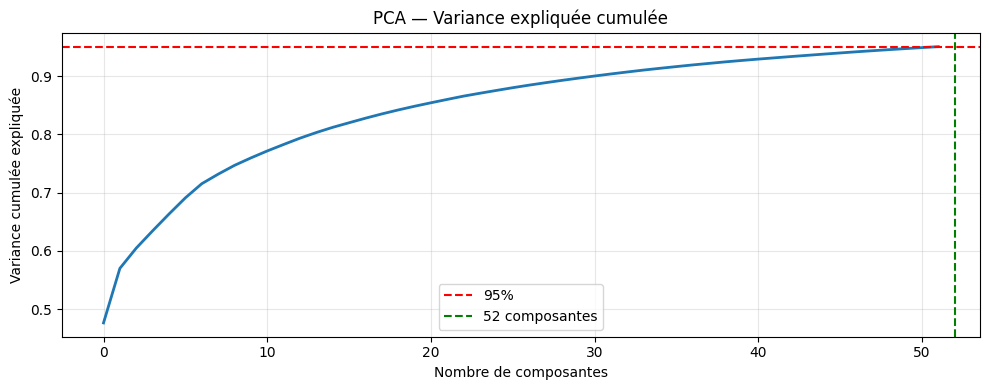

CPU times: user 1min 24s, sys: 3.79 s, total: 1min 28s
Wall time: 30.2 s


3445

In [8]:
%%time
# Mémoriser le test_kaggle aligné sur FEATURES avant transformation
X_kaggle_raw = test_kaggle[FEATURES].copy()

# 1) StandardScaler (fit sur X_tr seulement)
scaler = StandardScaler()
X_tr_sc     = scaler.fit_transform(X_tr)
X_val_sc    = scaler.transform(X_val)
X_te_sc     = scaler.transform(X_te)
X_kaggle_sc = scaler.transform(X_kaggle_raw)

# 2) PCA — on garde 95% de la variance (fit sur X_tr seulement)
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_tr_pca     = pca.fit_transform(X_tr_sc)
X_val_pca    = pca.transform(X_val_sc)
X_te_pca     = pca.transform(X_te_sc)
X_kaggle_pca = pca.transform(X_kaggle_sc)

n_comp = pca.n_components_
print(f'Avant PCA : {len(FEATURES)} features')
print(f'Après PCA : {n_comp} composantes (95% variance expliquée)')
print(f'Variance expliquée totale : {pca.explained_variance_ratio_.sum():.4f}')

# 3) Reconstruire des DataFrames avec des noms de colonnes PC1..PCn
PCA_FEATURES = [f'PC{i+1}' for i in range(n_comp)]
X_tr     = pd.DataFrame(X_tr_pca,     columns=PCA_FEATURES, index=X_tr.index)
X_val    = pd.DataFrame(X_val_pca,    columns=PCA_FEATURES, index=X_val.index)
X_te     = pd.DataFrame(X_te_pca,     columns=PCA_FEATURES, index=X_te.index)
X_kaggle = pd.DataFrame(X_kaggle_pca, columns=PCA_FEATURES, index=X_kaggle_raw.index)

# Plot variance cumulée
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), lw=2)
plt.axhline(0.95, color='r', ls='--', label='95%')
plt.axvline(n_comp, color='g', ls='--', label=f'{n_comp} composantes')
plt.xlabel('Nombre de composantes'); plt.ylabel('Variance cumulée expliquée')
plt.title('PCA — Variance expliquée cumulée'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

del X_tr_sc, X_val_sc, X_te_sc, X_kaggle_sc, X_tr_pca, X_val_pca, X_te_pca, X_kaggle_pca
gc.collect()


## 9. Fonction d'évaluation (AUC-ROC + AUC-PR)

In [9]:
results = []
def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred)
    auc_pr  = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    pr, rc, _   = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc, pr,   color=color, label=f'{name} (AP={auc_pr:.4f})')
    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}')
    results.append({'model': name, 'split': split_name, 'auc_roc': auc_roc, 'auc_pr': auc_pr})
    return auc_roc, auc_pr

## 10. LightGBM (hyperparamètres optimisés sur features PCA)

Paramètres alignés sur la solution 1ère place : `num_leaves=512`, `lr=0.03`, `feature_fraction=0.5`, early stopping sur AUC-PR.


In [10]:
%%time
def auc_pr_lgb(y_pred, dataset):
    return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

lgb_params = {
    'objective': 'binary',
    'metric': 'None',
    'learning_rate': 0.03,
    'num_leaves': 512,
    'min_child_samples': 80,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'is_unbalance': True,
    'verbose': -1,
}
dtr = lgb.Dataset(X_tr, y_tr)
dvl = lgb.Dataset(X_val, y_val)
model_lgb = lgb.train(lgb_params, dtr, num_boost_round=3000,
                      valid_sets=[dvl], feval=auc_pr_lgb,
                      callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)])
pred_lgb_val = model_lgb.predict(X_val)
pred_lgb_te  = model_lgb.predict(X_te)
print('LightGBM:')
evaluate(y_val, pred_lgb_val, 'LightGBM', 'val')
evaluate(y_te,  pred_lgb_te,  'LightGBM', 'test')

Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc_pr: 0.42508
[400]	valid_0's auc_pr: 0.443115
[600]	valid_0's auc_pr: 0.448255
[800]	valid_0's auc_pr: 0.45097
[1000]	valid_0's auc_pr: 0.452886
[1200]	valid_0's auc_pr: 0.454839
[1400]	valid_0's auc_pr: 0.456123
[1600]	valid_0's auc_pr: 0.457568
[1800]	valid_0's auc_pr: 0.458658
[2000]	valid_0's auc_pr: 0.459074
[2200]	valid_0's auc_pr: 0.460085
[2400]	valid_0's auc_pr: 0.460473
[2600]	valid_0's auc_pr: 0.460895
[2800]	valid_0's auc_pr: 0.461055
Early stopping, best iteration is:
[2733]	valid_0's auc_pr: 0.461355
LightGBM:
  val   | AUC-ROC: 0.8656 | AUC-PR: 0.4614
  test  | AUC-ROC: 0.8292 | AUC-PR: 0.3473
CPU times: user 30min 48s, sys: 11.1 s, total: 30min 59s
Wall time: 8min 6s


(np.float64(0.8291720105025081), np.float64(0.3472886275582859))

## 11. Évaluation finale + courbes (sur test held-out)

  test  | AUC-ROC: 0.8292 | AUC-PR: 0.3473


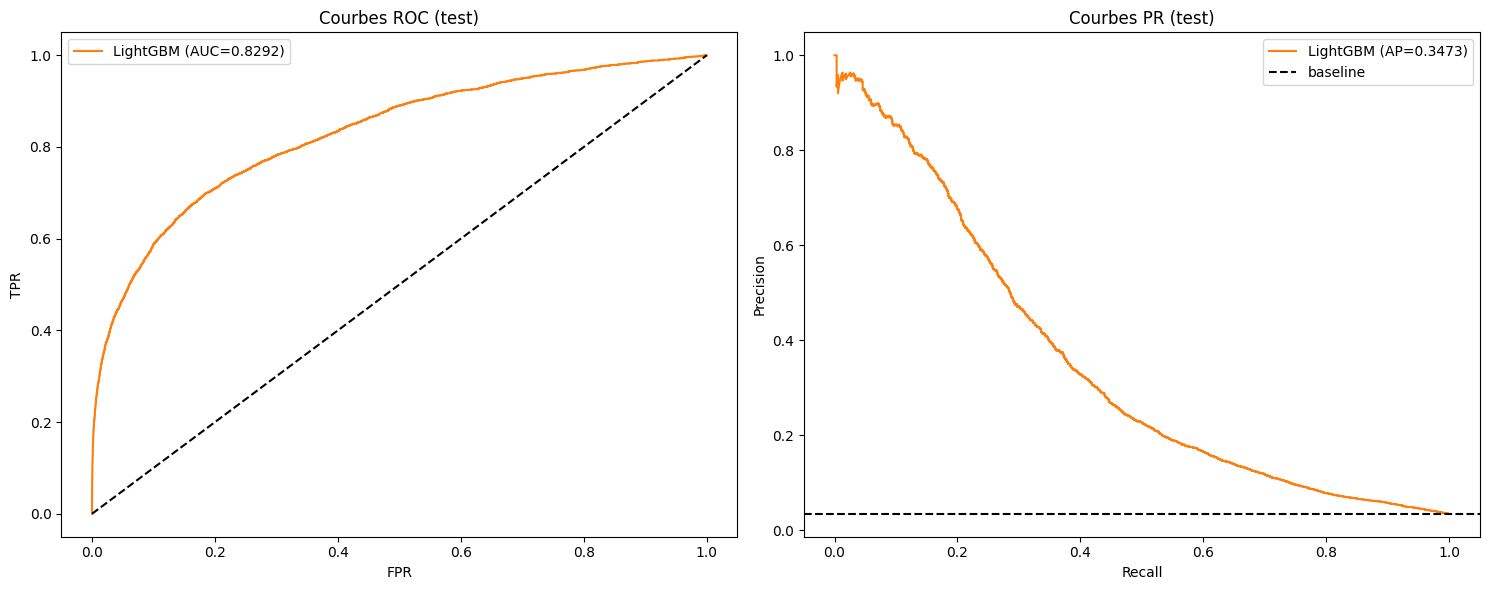

auc_pr             auc_roc          
split         test       val      test       val
model                                           
LightGBM  0.347289  0.461355  0.829172  0.865555

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
evaluate(y_te, pred_lgb_te, 'LightGBM', 'test', ax1, ax2, 'C1')
ax1.plot([0,1],[0,1],'k--'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Courbes ROC (test)'); ax1.legend()
ax2.axhline(y_te.mean(), color='k', ls='--', label='baseline')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbes PR (test)'); ax2.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(results).pivot_table(index='model', columns='split', values=['auc_roc','auc_pr'])


## 12. Feature Importance (top 30 composantes PCA)

Les features étant maintenant des composantes PCA, on affiche les composantes les plus importantes pour LightGBM (par gain). Pour interpréter une `PCi` particulière, on peut la décomposer via `pca.components_[i]` qui donne ses poids sur les features originales.


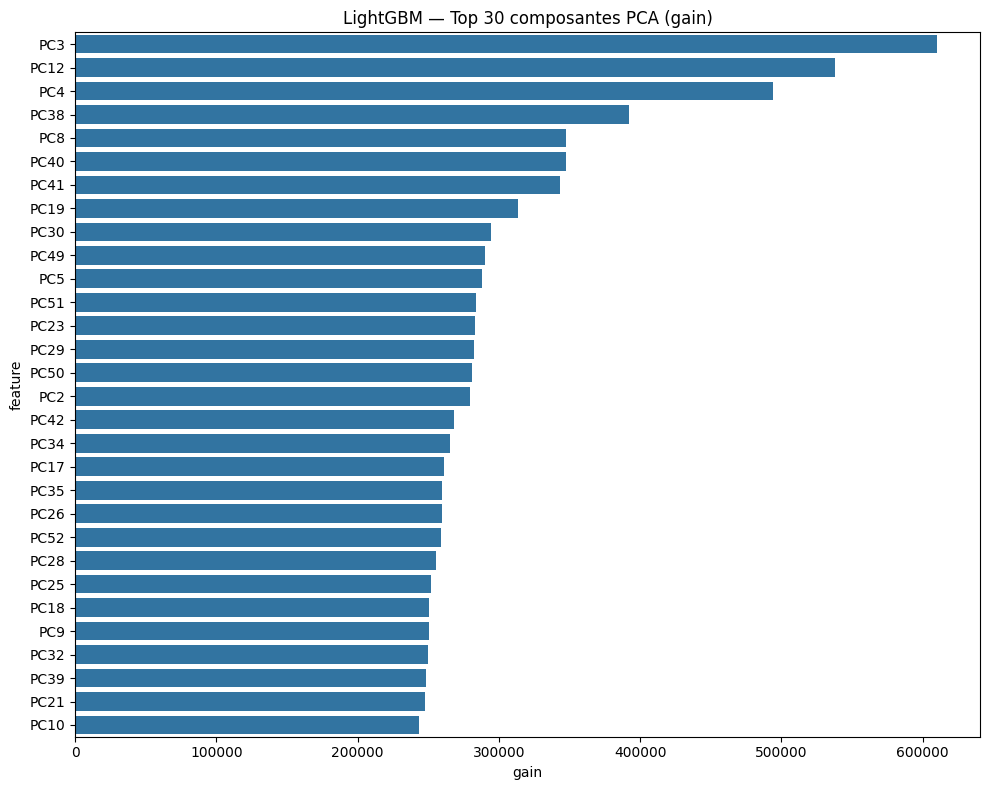


--- Décomposition de PC3 (top 10 features originales par |poids|) ---
V279    0.2283
V293    0.2254
V280    0.2244
V287    0.2218
V290    0.2217
V298    0.2214
V295    0.2194
V299    0.2185
V284    0.2174
V297    0.2172


In [12]:
imp = pd.DataFrame({'feature': PCA_FEATURES,
                    'gain': model_lgb.feature_importance(importance_type='gain')})
imp = imp.sort_values('gain', ascending=False).head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp, y='feature', x='gain')
plt.title('LightGBM — Top 30 composantes PCA (gain)')
plt.tight_layout(); plt.show()

# Bonus : pour la composante #1 du top, montrer les 10 features originales avec le plus gros poids
top_pc = imp.iloc[0]['feature']               # ex. 'PC7'
top_pc_idx = int(top_pc.replace('PC', '')) - 1
loadings = pd.Series(pca.components_[top_pc_idx], index=FEATURES).abs().sort_values(ascending=False)
print(f'\n--- Décomposition de {top_pc} (top 10 features originales par |poids|) ---')
print(loadings.head(10).round(4).to_string())
